In [71]:
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt

In [72]:
from sklearn.datasets import make_classification
# Выбрать подходящую таблицу данных.
data, target = make_classification(
    n_samples=5000,      # наблюдений
    n_features=20,
    n_informative=5,     # информативные признаки
    n_redundant=5,       # избыточные признаки
    n_classes=2,
    class_sep=0.8,       # степень разделимости классов
    random_state=42,
)

feature_names = [f'feature_{i}' for i in range(data.shape[1])]
target_names = ['class_0', 'class_1']

In [73]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

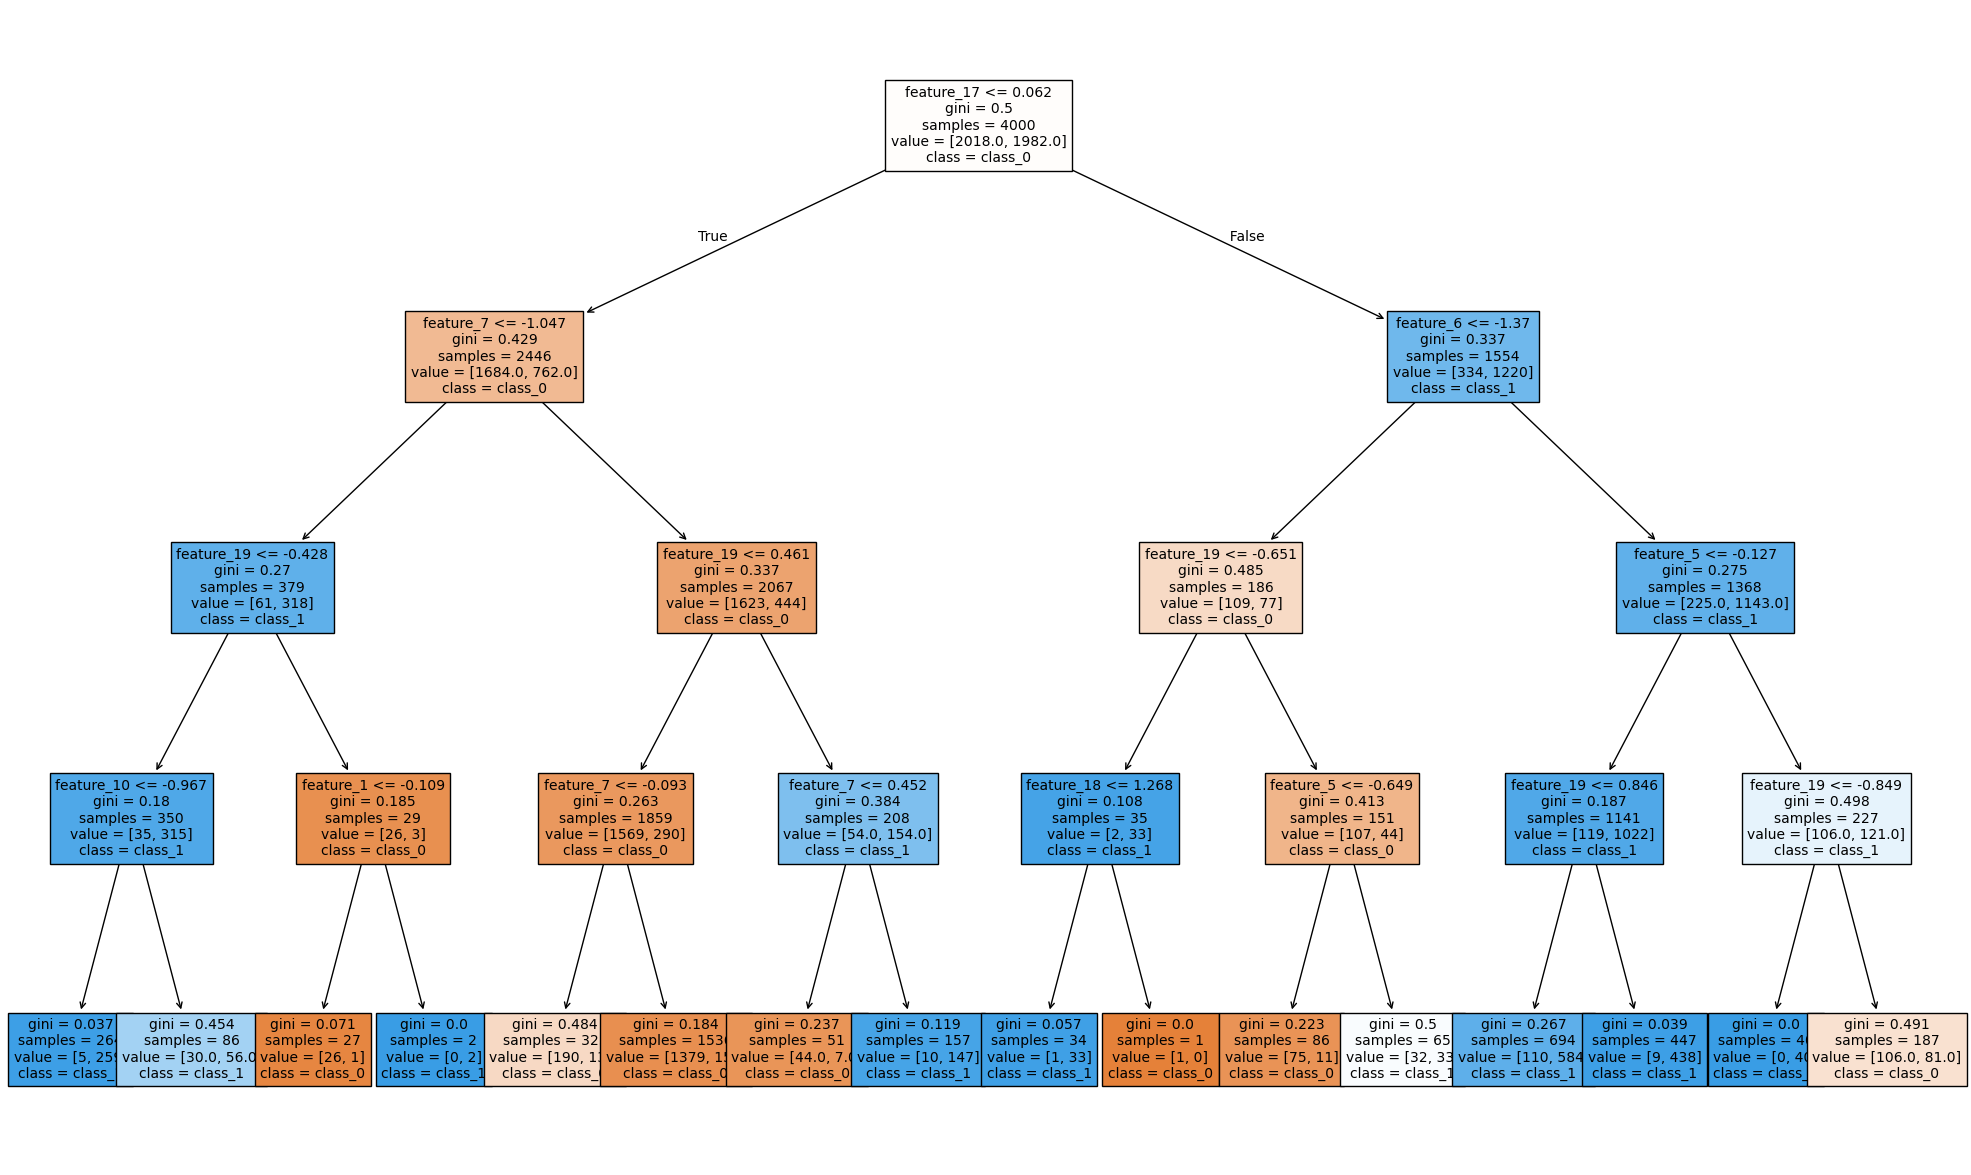

In [74]:
# Построить и визуализировать дерево решений.
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(train_data, train_target)

plt.figure(figsize=(25, 15))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    fontsize=10
)
plt.show()

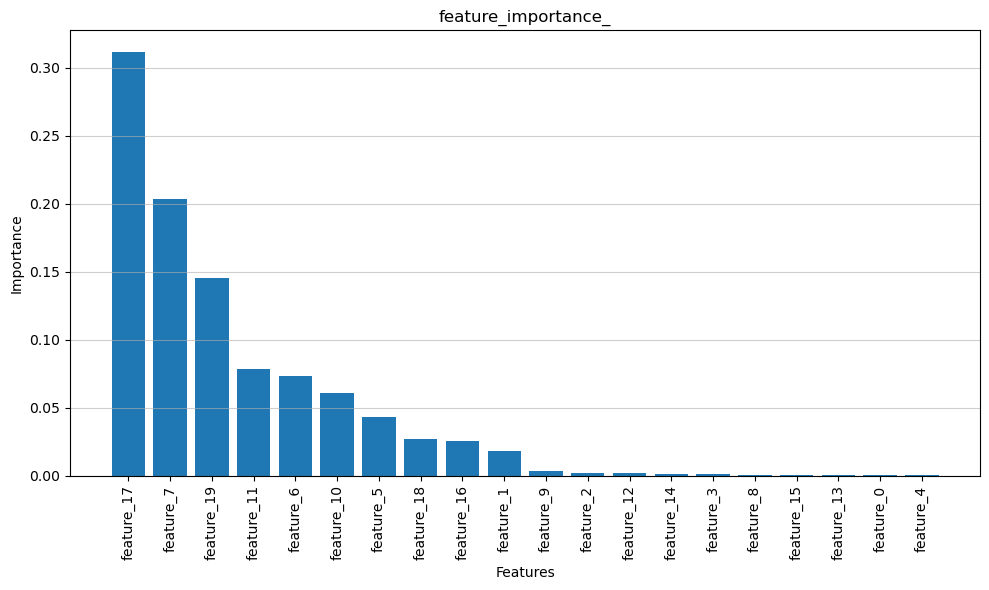

[[DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                        random_state=RandomState(MT19937) at 0x3175ACA40)]
 [DecisionTreeRegressor(criterion=

In [75]:
# Применить метод градиентного бустинга. Вычислить значимость переменных. 
# Выдать список построенных деревьев.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

# строит несколько деревьев - обЪединяет их в одно
# Аналог Мегазорда из Power Rangers
model = GradientBoostingClassifier(random_state=42)
model.fit(train_data, train_target)

importances = model.feature_importances_
feature_names = [f'feature_{i}' for i in range(train_data.shape[1])]

indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), sorted_features, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("feature_importance_")
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

print(model.estimators_)

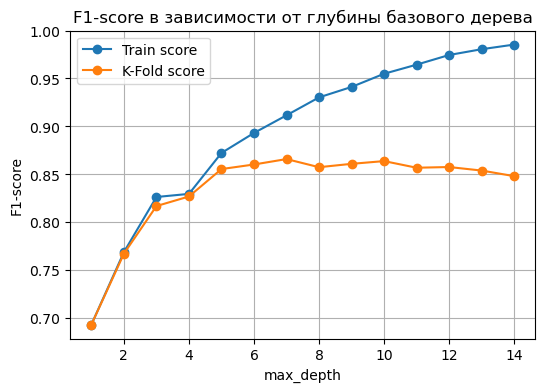

In [76]:
# Построить зависимость качества решения (на обучении и скользящем контроле)
# от числа вершин дерева.
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.model_selection import cross_val_score, KFold

# делим на фолды, тренируем на n-1 фолдах, тренируем на 1
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = make_scorer(f1_score)


depths = [i for i in range(1, 15)]
train_scores = []
kfold_scores = []
for i in depths:
    model = DecisionTreeClassifier(max_depth=i, random_state=42)
    model.fit(data, target)
    preds = model.predict(data)

    train_score = f1_score(target, preds)
    train_scores.append(train_score)

    kfold_score = cross_val_score(model, data, target, cv=kf, scoring=scoring).mean()
    kfold_scores.append(kfold_score)



plt.figure(figsize=(6, 4))
plt.plot(depths, train_scores, marker='o', label='Train score')
plt.plot(depths, kfold_scores, marker='o', label='K-Fold score')
plt.title('F1-score в зависимости от глубины базового дерева')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.grid(True)
plt.legend() 
plt.show()

Finished model with n_estimators=2000 and max_depth=5
Finished model with n_estimators=1800 and max_depth=5
Finished model with n_estimators=1600 and max_depth=5
Finished model with n_estimators=1400 and max_depth=5
Finished model with n_estimators=1200 and max_depth=5
Finished model with n_estimators=1000 and max_depth=5
Finished model with n_estimators=800 and max_depth=5
Finished model with n_estimators=600 and max_depth=5
Finished model with n_estimators=500 and max_depth=5
Finished model with n_estimators=400 and max_depth=5
Finished model with n_estimators=350 and max_depth=5
Finished model with n_estimators=300 and max_depth=5
Finished model with n_estimators=250 and max_depth=5
Finished model with n_estimators=200 and max_depth=5
Finished model with n_estimators=150 and max_depth=5
Finished model with n_estimators=100 and max_depth=5
Finished model with n_estimators=50 and max_depth=5
Finished model with n_estimators=30 and max_depth=5
Finished model with n_estimators=20 and ma

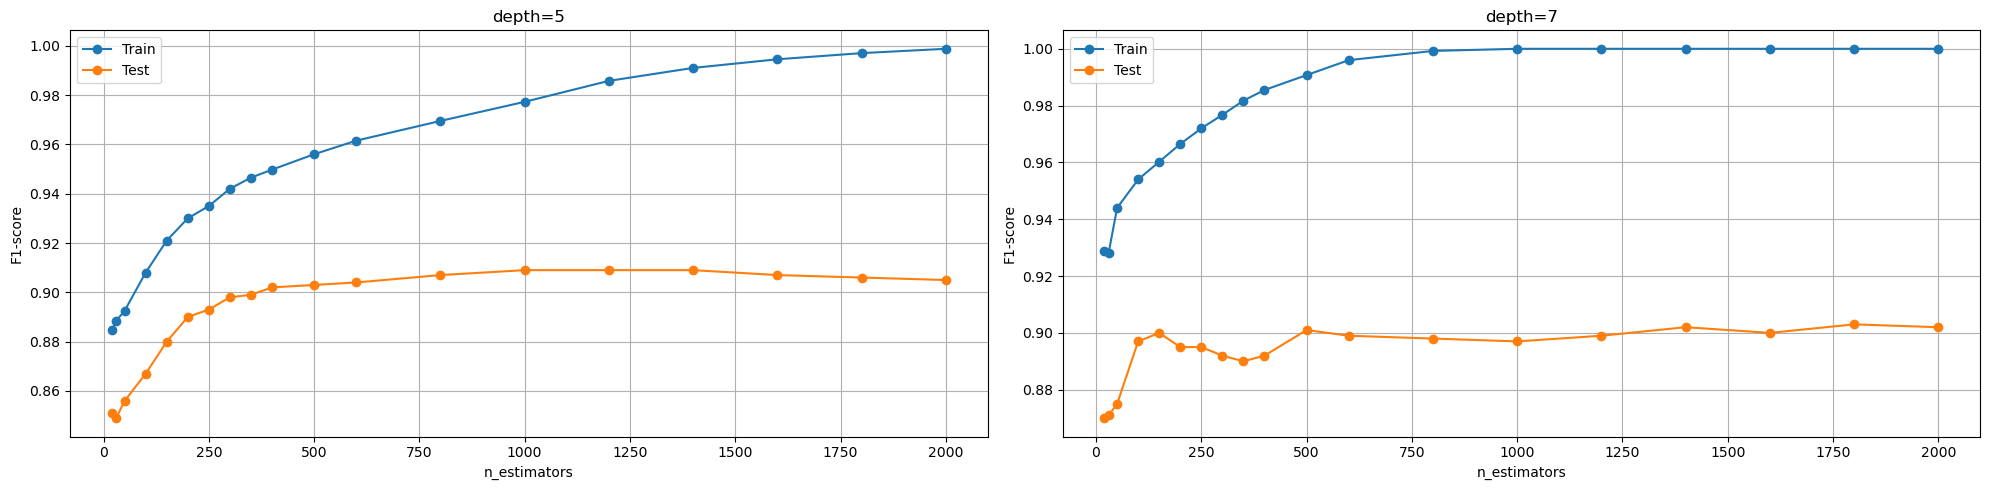

In [77]:
# Для метода градиентного бустинга построить зависимость качества решения 
# (на обучении и скользящем контроле) от числа деревьев.
# Для разной глубины дерева нужно построить несколько зависимостей качества 
# от числа деревьев, чтобы найти оптимальную комбинацию этих параметров.

n_estimators_list = [20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
depths = [5, 7]

fig, axes = plt.subplots(1, len(depths), figsize=(20, 5))
axes.flatten()

for depth, i in zip(depths, range(len(depths))):
    train_scores = []
    test_scores = []

    model = GradientBoostingClassifier(
        n_estimators=max(n_estimators_list), 
        max_depth=depth, 
        random_state=42, 
        learning_rate=0.01
    )
    model.fit(train_data, train_target)
    
    all_train_predictions = list(model.staged_predict(train_data))
    all_test_predictions = list(model.staged_predict(test_data))

    for n_est in reversed(n_estimators_list):
        train_score = accuracy_score(train_target, all_train_predictions[n_est-1])
        test_score = accuracy_score(test_target, all_test_predictions[n_est-1])
        train_scores.append(train_score)
        test_scores.append(test_score)

        print(f"Finished model with n_estimators={n_est} and max_depth={depth}")


    train_scores.reverse()
    test_scores.reverse()

    axes[i].plot(n_estimators_list, train_scores, marker='o', label='Train')
    axes[i].plot(n_estimators_list, test_scores, marker='o', label='Test')
    axes[i].set_title(f'depth={depth}')
    axes[i].set_xlabel('n_estimators')
    axes[i].set_ylabel('F1-score')
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

Finished model with n_estimators=1200, max_depth=5
Finished model with n_estimators=1000, max_depth=5
Finished model with n_estimators=800, max_depth=5
Finished model with n_estimators=600, max_depth=5
Finished model with n_estimators=500, max_depth=5
Finished model with n_estimators=400, max_depth=5
Finished model with n_estimators=350, max_depth=5
Finished model with n_estimators=300, max_depth=5
Finished model with n_estimators=250, max_depth=5
Finished model with n_estimators=200, max_depth=5
Finished model with n_estimators=150, max_depth=5
Finished model with n_estimators=100, max_depth=5
Finished model with n_estimators=50, max_depth=5
Finished model with n_estimators=30, max_depth=5
Finished model with n_estimators=20, max_depth=5


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Finished model with n_estimators=1200, max_depth=7
Finished model with n_estimators=1000, max_depth=7
Finished model with n_estimators=800, max_depth=7
Finished model with n_estimators=600, max_depth=7
Finished model with n_estimators=500, max_depth=7
Finished model with n_estimators=400, max_depth=7
Finished model with n_estimators=350, max_depth=7
Finished model with n_estimators=300, max_depth=7
Finished model with n_estimators=250, max_depth=7
Finished model with n_estimators=200, max_depth=7
Finished model with n_estimators=150, max_depth=7
Finished model with n_estimators=100, max_depth=7
Finished model with n_estimators=50, max_depth=7
Finished model with n_estimators=30, max_depth=7
Finished model with n_estimators=20, max_depth=7


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Finished model with n_estimators=1200, max_depth=10
Finished model with n_estimators=1000, max_depth=10
Finished model with n_estimators=800, max_depth=10
Finished model with n_estimators=600, max_depth=10
Finished model with n_estimators=500, max_depth=10
Finished model with n_estimators=400, max_depth=10
Finished model with n_estimators=350, max_depth=10
Finished model with n_estimators=300, max_depth=10
Finished model with n_estimators=250, max_depth=10
Finished model with n_estimators=200, max_depth=10
Finished model with n_estimators=150, max_depth=10
Finished model with n_estimators=100, max_depth=10
Finished model with n_estimators=50, max_depth=10
Finished model with n_estimators=30, max_depth=10


...

Finished model with n_estimators=20, max_depth=10
Finished model with n_estimators=1200, max_depth=15
Finished model with n_estimators=1000, max_depth=15
Finished model with n_estimators=800, max_depth=15
Finished model with n_estimators=600, max_depth=15
Finished model with n_estimators=500, max_depth=15
Finished model with n_estimators=400, max_depth=15
Finished model with n_estimators=350, max_depth=15
Finished model with n_estimators=300, max_depth=15
Finished model with n_estimators=250, max_depth=15
Finished model with n_estimators=200, max_depth=15
Finished model with n_estimators=150, max_depth=15
Finished model with n_estimators=100, max_depth=15
Finished model with n_estimators=50, max_depth=15
Finished model with n_estimators=30, max_depth=15


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Finished model with n_estimators=20, max_depth=15
Finished model with n_estimators=1200, max_depth=20
Finished model with n_estimators=1000, max_depth=20
Finished model with n_estimators=800, max_depth=20
Finished model with n_estimators=600, max_depth=20
Finished model with n_estimators=500, max_depth=20
Finished model with n_estimators=400, max_depth=20
Finished model with n_estimators=350, max_depth=20
Finished model with n_estimators=300, max_depth=20
Finished model with n_estimators=250, max_depth=20
Finished model with n_estimators=200, max_depth=20
Finished model with n_estimators=150, max_depth=20
Finished model with n_estimators=100, max_depth=20
Finished model with n_estimators=50, max_depth=20
Finished model with n_estimators=30, max_depth=20


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Finished model with n_estimators=20, max_depth=20


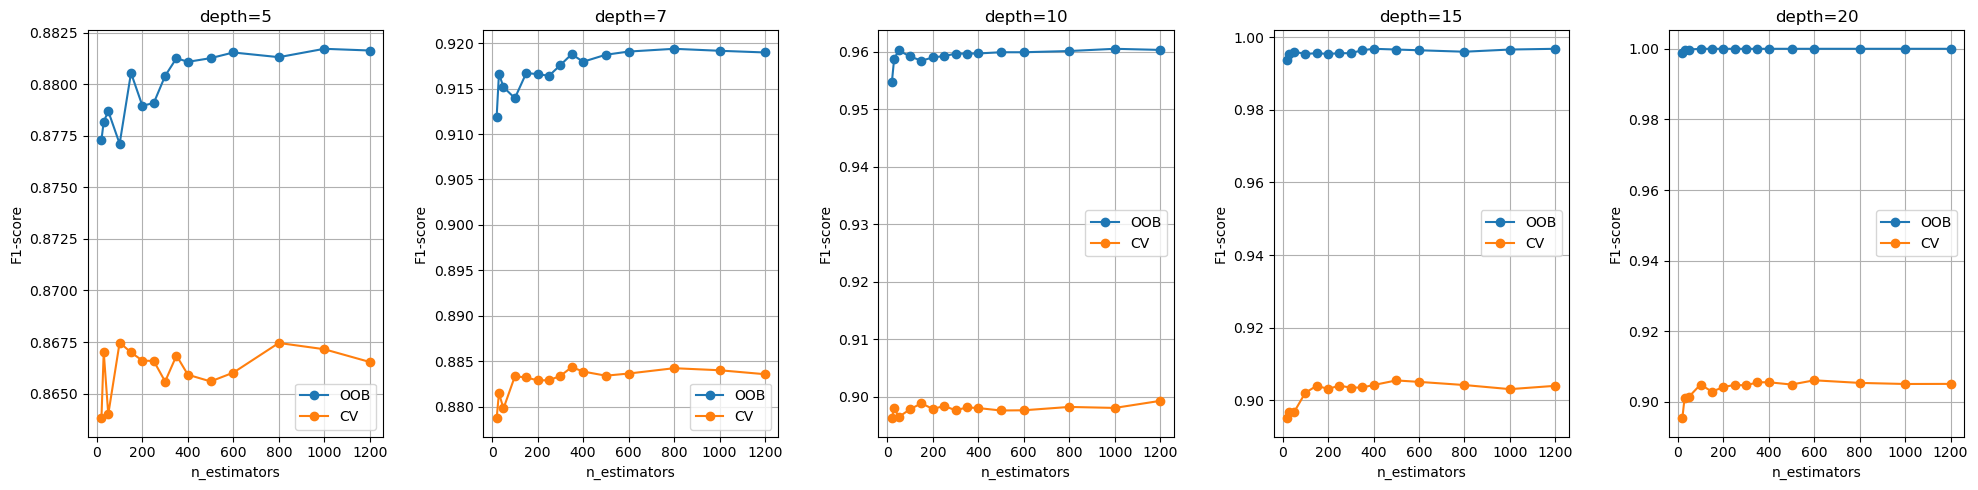

Exception ignored in: <function ResourceTracker.__del__ at 0x1054d5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106bf9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1193a5bc0>
Traceback (most recent call last

In [78]:
# Выполнить предыдущий пункт для случайного леса. 
# Сравнить оценку out-of-bag с оценкой по кроссвалидации.
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 800, 1000, 1200]
depths = [5, 7, 10, 15, 20]

fig, axes = plt.subplots(1, len(depths), figsize=(20, 5))
axes.flatten()

for depth, i in zip(depths, range(len(depths))):
    oob_scores = []
    kfold_scores = []
    for n_est in reversed(n_estimators_list):
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            oob_score=True,
            n_jobs=-1
        )
        model.fit(data, target)

        oob_preds = model.predict(data)
        oob_score = f1_score(target, oob_preds)
        oob_scores.append(oob_score)

        kfold_score = cross_val_score(model, data, target, cv=kf, scoring='f1', n_jobs=-1).mean()
        kfold_scores.append(kfold_score)

        print(f"Finished model with n_estimators={n_est}, max_depth={depth}")

    oob_scores.reverse()
    kfold_scores.reverse()

    axes[i].plot(n_estimators_list, oob_scores, marker='o', label='OOB')
    axes[i].plot(n_estimators_list, kfold_scores, marker='o', label='CV')
    axes[i].set_title(f'depth={depth}')
    axes[i].set_xlabel('n_estimators')
    axes[i].set_ylabel('F1-score')
    axes[i].grid(True)
    axes[i].legend()


plt.tight_layout()
plt.show()
    